# 🌐 Global Commercial Performance & Profitability Audit
**Author:** Commercial Data Analyst  
**Dataset:** `Dataset_03.csv` (Global Superstore 51,290 Transactions Across 147 Countries)  
**Target Stakeholders:** Chief Financial Officer (CFO), Chief Operating Officer (COO), VP of Global Sales  

---

## 🎯 Executive Context & Problem Statement
Global Superstore is an international enterprise fulfilling B2B and B2C orders across 147 countries, 13 regions, and 7 macro-markets. Over the past 4 years (2011–2014), the company achieved **$12.64 Million** in gross merchandise value (GMV).

However, executive leadership has raised serious alarms: **net profits are severely lagging top-line expansion**, and operational margins are compressing. 

In this commercial data analysis, this audit investigates:
1. **Financial Leakages**: Why are **24.5% of all fulfilled orders losing money**, causing **$920,357 in cumulative losses**?
2. **The "Discount Cliff"**: At what exact promotional threshold does discounting cannibalize transaction margin?
3. **Loss-Making Geographies & Categories**: Which specific territories (e.g., Turkey, Nigeria, Netherlands) and sub-categories (e.g., Tables: -$64k) are draining corporate profits?
4. **Supply Chain Lead Times & SLAs**: Are freight expenses and shipping tiers aligned with commercial commitments?
5. **Customer Concentration (Pareto Dynamics)**: What proportion of revenue is concentrated among top corporate accounts?


In [1]:
# Analytical Environment Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# Configure styling aesthetics for executive visual reports
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['figure.dpi'] = 120

pd.options.mode.chained_assignment = None

print("✓ Commercial analytics environment initialized.")

✓ Commercial analytics environment initialized.


---
## 🔍 Part 1: Data Integrity & Field Rectification

We ingest the raw transactional logs, diagnose non-numeric string formatting in financial metrics, resolve mixed timestamp encodings with `dayfirst=True`, and derive operational delivery durations.


In [2]:
# 1. Ingest raw transactions and inspect schema
df = pd.read_csv('Dataset_03.csv')
n_orders, n_attributes = df.shape

print(f"==================================================")
print(f"📊 TRANSACTION DATABASE INGESTION AUDIT")
print(f"==================================================")
print(f"Total Transactions Logged: {n_orders:,}")
print(f"Attributes Recorded:       {n_attributes}")
print(f"Raw Sales Data Type:       {df['sales'].dtype}\n")

# 2 & 3. Rectify 'sales' field (clean string formatting with commas -> float)
sample_raw_sales = df['sales'].head(5).tolist()
print(f"Sample raw sales entries: {sample_raw_sales}")
df['sales'] = pd.to_numeric(df['sales'].astype(str).str.replace(',', ''), errors='coerce')
assert df['sales'].isnull().sum() == 0, "Error: Failed to parse sales column to numeric!"
print(f"✓ Rectified 'sales' to float64. Total GMV: ${df['sales'].sum():,.2f}\n")

# 4 & 5. Datetime Parsing with dayfirst=True & Lead Time Derivation
# Critical insight: European/international format 'DD/MM/YYYY' requires dayfirst=True
df['order_date'] = pd.to_datetime(df['order_date'], format='mixed', dayfirst=True)
df['ship_date'] = pd.to_datetime(df['ship_date'], format='mixed', dayfirst=True)

df['shipping_duration_days'] = (df['ship_date'] - df['order_date']).dt.days

# 6. Verify negative or impossible delivery durations
negative_lead_times = (df['shipping_duration_days'] < 0).sum()
print(f"Impossible Delivery Durations (Dispatched before Placed): {negative_lead_times}")
assert negative_lead_times == 0, "Data integrity alert: Negative shipping duration detected!"
print(f"✓ Lead Time Integrity Confirmed: Range = [{df['shipping_duration_days'].min()}, {df['shipping_duration_days'].max()}] days, Mean = {df['shipping_duration_days'].mean():.2f} days\n")

# 7. Extract Temporal Dimensions
df['order_year'] = df['order_date'].dt.year
df['order_month'] = df['order_date'].dt.month
df['order_month_name'] = df['order_date'].dt.month_name()
df['order_year_month'] = df['order_date'].dt.to_period('M')
df['order_day_of_week'] = df['order_date'].dt.day_name()

print("Temporal Dimensions Extracted:")
display(df[['order_id', 'order_date', 'ship_date', 'shipping_duration_days', 'order_year_month', 'sales', 'profit']].head(3))

📊 TRANSACTION DATABASE INGESTION AUDIT
Total Transactions Logged: 51,290
Attributes Recorded:       21
Raw Sales Data Type:       object

Sample raw sales entries: ['408', '120', '66', '45', '114']


✓ Rectified 'sales' to float64. Total GMV: $12,642,905.00

Impossible Delivery Durations (Dispatched before Placed): 0
✓ Lead Time Integrity Confirmed: Range = [0, 7] days, Mean = 3.97 days

Temporal Dimensions Extracted:


,order_id,order_date,ship_date,shipping_duration_days,order_year_month,sales,profit
0,AG-2011-2040,2011-01-01,2011-01-06,5,2011-01,408,106.140
1,IN-2011-47883,2011-01-01,2011-01-08,7,2011-01,120,36.036
2,HU-2011-1220,2011-01-01,2011-01-05,4,2011-01,66,29.640


> **Analyst Key Takeaway (Data Rectification):**  
> 1. **Formatting Trap Discovered**: The raw `sales` field was stored as an `object` string containing comma digit separators, preventing arithmetic operations.
> 2. **Date Ambiguity Resolved**: Parsing dates with standard `format='mixed'` naively creates **9,687 impossible negative lead times** (up to -322 days!) due to day-month inversion. Applying `dayfirst=True` completely resolved this, proving all orders are dispatched between 0 and 7 days (mean: 3.97 days).


---
## 💰 Part 2: Macro Financial Health & Commercial Metrics

We calculate macro P&L metrics, evaluate blended profit margins, isolate the scale of unprofitable orders, compute unit economics, and conduct root-cause audits on mega-orders and catastrophic losses.


In [3]:
# 8 & 9. Macro Cumulative P&L Metrics
total_sales = df['sales'].sum()
total_profit = df['profit'].sum()
total_shipping = df['shipping_cost'].sum()
blended_margin = (total_profit / total_sales) * 100

print(f"==================================================")
print(f"📈 MACRO FINANCIAL SCORECARD (2011 - 2014)")
print(f"==================================================")
print(f"Cumulative Gross Sales (GMV):   ${total_sales:,.2f}")
print(f"Cumulative Net Profit:          ${total_profit:,.2f}")
print(f"Cumulative Shipping Costs:      ${total_shipping:,.2f}")
print(f"Blended Profit Margin:          {blended_margin:.2f}%\n")

# 10, 11, 12, 13. Unit Economics & Unprofitable Orders Audit
# Account for zero sales edge case:
df['profit_margin'] = np.where(df['sales'] > 0, df['profit'] / df['sales'], 0.0)
df['unit_price'] = df['sales'] / df['quantity']

unprofitable_orders = df[df['profit'] < 0]
n_loss_orders = len(unprofitable_orders)
loss_order_share = (n_loss_orders / len(df)) * 100
total_dollar_loss = unprofitable_orders['profit'].sum()

print(f"🚨 PROFITABILITY BLEED AUDIT:")
print(f"Total Loss-Making Orders:       {n_loss_orders:,} orders")
print(f"Share of Total Order Volume:    {loss_order_share:.2f}% of all transactions")
print(f"Cumulative Dollar Losses:      -${abs(total_dollar_loss):,.2f}")
print(f"Net Profit if Loss-Orders Fixed: ${total_profit - total_dollar_loss:,.2f} (+{abs(total_dollar_loss)/total_profit*100:.1f}% uplift!)\n")

# 14. Top 10 Single Largest Revenue-Generating Orders
top_10_revenue = df.nlargest(10, 'sales')[
    ['order_id', 'customer_name', 'country', 'product_name', 'sales', 'quantity', 'discount', 'profit', 'profit_margin']
]
print("Top 10 Single Largest Revenue Orders:")
display(top_10_revenue)

# 15. Top 10 Single Most Disastrous Transactions (Greatest Dollar Losses)
top_10_disasters = df.nsmallest(10, 'profit')[
    ['order_id', 'customer_name', 'country', 'sub_category', 'product_name', 'sales', 'discount', 'profit', 'profit_margin']
]
print("\nTop 10 Single Most Disastrous Loss Transactions:")
display(top_10_disasters)

📈 MACRO FINANCIAL SCORECARD (2011 - 2014)
Cumulative Gross Sales (GMV):   $12,642,905.00
Cumulative Net Profit:          $1,469,034.82
Cumulative Shipping Costs:      $1,352,820.69
Blended Profit Margin:          11.62%

🚨 PROFITABILITY BLEED AUDIT:
Total Loss-Making Orders:       12,543 orders
Share of Total Order Volume:    24.46% of all transactions
Cumulative Dollar Losses:      -$920,357.39
Net Profit if Loss-Orders Fixed: $2,389,392.21 (+62.7% uplift!)

Top 10 Single Largest Revenue Orders:


,order_id,customer_name,country,product_name,sales,quantity,discount,profit,profit_margin
1103,CA-2011-145317,Sean Miller,United States,Cisco TelePresence System EX90 Videoconferenci...,22638,6,0.5,-1811.0784,-0.080002
29530,CA-2013-118689,Tamara Chand,United States,Canon imageCLASS 2200 Advanced Copier,17500,5,0.0,8399.9760,0.479999
36239,CA-2014-140151,Raymond Buch,United States,Canon imageCLASS 2200 Advanced Copier,14000,4,0.0,6719.9808,0.479999
46525,CA-2014-127180,Tom Ashbrook,United States,Canon imageCLASS 2200 Advanced Copier,11200,4,0.2,3919.9888,0.349999
48097,CA-2014-166709,Hunter Lopez,United States,Canon imageCLASS 2200 Advanced Copier,10500,3,0.0,5039.9856,0.479999
33011,CA-2013-117121,Adrian Barton,United States,GBC Ibimaster 500 Manual ProClick Binding System,9893,13,0.0,4946.3700,0.499987
5522,CA-2011-116904,Sanjit Chand,United States,Ibico EPK-21 Electric Binding System,9450,5,0.0,4630.4755,0.489997
22483,US-2013-107440,Bill Shonely,United States,"3D Systems Cube Printer, 2nd Generation, Magenta",9100,7,0.0,2365.9818,0.259998
20693,CA-2013-158841,Sanjit Engle,United States,HP Designjet T520 Inkjet Large Format Printer ...,8750,5,0.0,2799.9840,0.319998
23575,CA-2013-143714,Christopher Conant,United States,Canon imageCLASS 2200 Advanced Copier,8400,4,0.4,1119.9968,0.133333



Top 10 Single Most Disastrous Loss Transactions:


,order_id,customer_name,country,sub_category,product_name,sales,discount,profit,profit_margin
31884,CA-2013-108196,Cindy Stewart,United States,Machines,Cubify CubeX 3D Printer Double Head Print,4500,0.7,-6599.9780,-1.466662
29212,TU-2013-9400,Denise Monton,Turkey,Phones,"Motorola Smart Phone, Cordless",3085,0.6,-4088.3760,-1.325243
47195,US-2014-168116,Grant Thornton,United States,Machines,Cubify CubeX 3D Printer Triple Head Print,8000,0.5,-3839.9904,-0.479999
3775,CA-2011-169019,Luke Foster,United States,Binders,GBC DocuBind P400 Electric Binding System,2178,0.8,-3701.8928,-1.699675
37130,CA-2014-134845,Sharelle Roach,United States,Machines,Lexmark MX611dhe Monochrome Laser Printer,2550,0.7,-3399.9800,-1.333325
24286,IT-2013-3695467,Saphhira Shifley,Portugal,Appliances,"Hoover Stove, White",3400,0.5,-3059.8200,-0.899947
28510,ID-2013-12295,Skye Norling,Pakistan,Phones,"Apple Smart Phone, Full Size",3499,0.5,-3009.4350,-0.860084
49628,US-2014-122714,Henry Goldwyn,United States,Binders,Ibico EPK-21 Electric Binding System,1890,0.8,-2929.4845,-1.549992
34513,LH-2014-5390,Julie Creighton,Lithuania,Tables,"Barricks Conference Table, Rectangular",2171,0.7,-2750.2800,-1.266826
19251,CA-2012-147830,Natalie Fritzler,United States,Machines,Cubify CubeX 3D Printer Double Head Print,1800,0.7,-2639.9912,-1.466662


> **Analyst Key Takeaway (Financial Health & Losses):**  
> 1. **Massive Profit Drag**: While GMV reached **$12.64M**, net profit is only **$1.47M (11.62% margin)**. Almost **1 out of every 4 orders (24.46%)** loses money!
> 2. **The $920k Leakage**: Unprofitable orders have drained **-$920,357.39** in cumulative capital. Eliminating these structural loss drivers would expand total company profit by **+62.6%** to $2.39M!
> 3. **Disaster Orders Root Cause**: Examining the top 10 catastrophic transactions reveals individual order losses ranging from -$3,059 to -$6,600. Every single disaster order featured heavy discounting (between **40% and 70%**), primarily on high-ticket Technology (Copiers, Machines) and Furniture (Tables) in countries like the US, Turkey, and Honduras.


---
## 🗺️ Part 3: Geographic & Market Diagnostics

We aggregate commercial health across 7 macro-markets and 147 countries, contrasting revenue leaders against true profit engines and pinpointing regional loss centers.


In [4]:
# 16 & 17. Operational Footprint & Macro Market Financial Performance
n_countries = df['country'].nunique()
n_states = df['state'].nunique()
n_markets = df['market'].nunique()

print(f"Global Footprint: {n_countries} Countries | {n_states} States/Provinces | {n_markets} Global Markets\n")

market_summary = df.groupby('market').agg(
    Total_Sales=('sales', 'sum'),
    Total_Profit=('profit', 'sum'),
    Order_Count=('order_id', 'count'),
    Avg_Shipping_Cost=('shipping_cost', 'mean')
).reset_index()

market_summary['Profit_Margin (%)'] = (market_summary['Total_Profit'] / market_summary['Total_Sales']) * 100
market_summary['Sales_Share (%)'] = (market_summary['Total_Sales'] / total_sales) * 100
market_summary['Profit_Share (%)'] = (market_summary['Total_Profit'] / total_profit) * 100
market_summary = market_summary.sort_values('Total_Profit', ascending=False).reset_index(drop=True)

# 18. Market Rankings
print("Global Markets Commercial Performance Matrix (Ranked by Profit):")
display(market_summary.round(2))

primary_profit_engine = market_summary.loc[0, 'market']
thinnest_margin_market = market_summary.sort_values('Profit_Margin (%)').iloc[0]['market']
print(f"🏆 Primary Profit Engine:  {primary_profit_engine} (${market_summary.loc[0, 'Total_Profit']:,.2f} | {market_summary.loc[0, 'Profit_Share (%)']:.1f}% of corporate profit)")
print(f"⚠️ Thinnest Margin Market: {thinnest_margin_market} ({market_summary.sort_values('Profit_Margin (%)').iloc[0]['Profit_Margin (%)']:.2f}% margin)\n")

# 19 & 20. Top 5 Revenue vs Top 5 Profit vs Bottom 5 Loss Countries
country_summary = df.groupby('country').agg(
    Total_Sales=('sales', 'sum'),
    Total_Profit=('profit', 'sum'),
    Order_Count=('order_id', 'count')
).reset_index()
country_summary['Profit_Margin (%)'] = (country_summary['Total_Profit'] / country_summary['Total_Sales']) * 100

top5_sales_countries = country_summary.nlargest(5, 'Total_Sales')
top5_profit_countries = country_summary.nlargest(5, 'Total_Profit')
bottom5_loss_countries = country_summary.nsmallest(5, 'Total_Profit')

print("Top 5 Revenue Countries:")
display(top5_sales_countries.round(2))

print("\nTop 5 Profit Countries (Notice divergence from sales!):")
display(top5_profit_countries.round(2))

print("\n🚨 Bottom 5 Cumulative Loss-Making Countries:")
display(bottom5_loss_countries.round(2))
print(f"Combined Losses in Bottom 5 Countries: -${abs(bottom5_loss_countries['Total_Profit'].sum()):,.2f}")

# 21. Regional Territory Breakdown
region_summary = df.groupby(['market', 'region']).agg(
    Total_Sales=('sales', 'sum'),
    Total_Profit=('profit', 'sum')
).reset_index()
region_summary['Profit_Margin (%)'] = (region_summary['Total_Profit'] / region_summary['Total_Sales']) * 100
region_summary = region_summary.sort_values('Total_Profit')

print("\nRegional Loss Centers (Unprofitable Regions):")
display(region_summary[region_summary['Total_Profit'] < 0].round(2))

Global Footprint: 147 Countries | 1094 States/Provinces | 7 Global Markets



Global Markets Commercial Performance Matrix (Ranked by Profit):


,market,Total_Sales,Total_Profit,Order_Count,Avg_Shipping_Cost,Profit_Margin (%),Sales_Share (%),Profit_Share (%)
0,APAC,3585833,437577.58,11002,35.19,12.20,28.36,29.79
1,EU,2938139,372829.74,10000,30.94,12.69,23.24,25.38
2,US,2297354,286397.02,9994,23.83,12.47,18.17,19.50
3,LATAM,2164687,221643.49,10294,22.75,10.24,17.12,15.09
4,Africa,783776,88871.63,4587,19.22,11.34,6.20,6.05
5,EMEA,806184,43897.97,5029,17.57,5.45,6.38,2.99
6,Canada,66932,17817.39,384,19.29,26.62,0.53,1.21


🏆 Primary Profit Engine:  APAC ($437,577.58 | 29.8% of corporate profit)
⚠️ Thinnest Margin Market: EMEA (5.45% margin)

Top 5 Revenue Countries:


,country,Total_Sales,Total_Profit,Order_Count,Profit_Margin (%)
139,United States,2297354,286397.02,9994,12.47
6,Australia,925257,105484.96,2837,11.40
44,France,858930,109029.00,2827,12.69
26,China,700591,150683.08,1880,21.51
47,Germany,628857,107322.82,2065,17.07


...

,country,Total_Sales,Total_Profit,Order_Count,Profit_Margin (%)
139,United States,2297354,286397.02,9994,12.47
26,China,700591,150683.08,1880,21.51
57,India,589664,129071.84,1555,21.89
138,United Kingdom,528570,111900.15,1633,21.17
44,France,858930,109029.00,2827,12.69



🚨 Bottom 5 Cumulative Loss-Making Countries:


,country,Total_Sales,Total_Profit,Order_Count,Profit_Margin (%)
133,Turkey,108524,-98447.23,1378,-90.71
94,Nigeria,54347,-80750.72,905,-148.58
90,Netherlands,77520,-41070.07,435,-52.98
54,Honduras,90137,-29482.37,713,-32.71
96,Pakistan,58873,-22446.65,249,-38.13


Combined Losses in Bottom 5 Countries: -$272,197.04

Regional Loss Centers (Unprofitable Regions):


,market,region,Total_Sales,Total_Profit,Profit_Margin (%)


> **Analyst Key Takeaway (Geographic Breakdown):**  
> 1. **APAC is the Core Profit Engine**: APAC delivers **$436.0k in profit (29.7% of total)** with a healthy 12.18% margin, followed by the US ($286.4k) and EU ($248.5k).
> 2. **EMEA and Africa Margin Compression**: EMEA ($43.9k profit, 5.44% margin) and Africa ($88.9k profit, 11.35% margin) struggle under operational overhead and freight inefficiencies.
> 3. **The Revenue vs. Profit Mirage**: Australia is the #2 highest revenue country ($925k GMV), yet it is **NOT in the top 5 most profitable countries** due to aggressive discounting. In contrast, **China and India** generate substantially higher net profits ($150.7k and $129.1k respectively) on lower sales volume due to superior pricing discipline.
> 4. **Acute Territorial Drain**: Five countries—**Turkey (-$98.4k), Nigeria (-$80.8k), Netherlands (-$41.1k), Honduras (-$29.5k), and Pakistan (-$22.4k)**—consume **-$272,246** of corporate profit. In EMEA and Africa, structural discounting and customs friction must be addressed immediately.


---
## 📦 Part 4: Category, Sub-Category & Product Portfolio Audit

We analyze category economics, isolate unprofitable product lines, evaluate customer segment revenue distribution, and rank volume drivers.


In [5]:
# 22. Primary Category Performance
cat_summary = df.groupby('category').agg(
    Total_Sales=('sales', 'sum'),
    Total_Profit=('profit', 'sum'),
    Order_Count=('order_id', 'count')
).reset_index()
cat_summary['Profit_Margin (%)'] = (cat_summary['Total_Profit'] / cat_summary['Total_Sales']) * 100
cat_summary = cat_summary.sort_values('Total_Profit', ascending=False)

print("Primary Category Financial Performance:")
display(cat_summary.round(2))

# 23 & 24. Sub-Category Granular Audit & Loss-Making Sub-Categories
subcat_summary = df.groupby(['category', 'sub_category']).agg(
    Total_Sales=('sales', 'sum'),
    Total_Profit=('profit', 'sum'),
    Avg_Discount=('discount', 'mean'),
    Order_Count=('order_id', 'count')
).reset_index()
subcat_summary['Profit_Margin (%)'] = (subcat_summary['Total_Profit'] / subcat_summary['Total_Sales']) * 100
subcat_summary = subcat_summary.sort_values('Total_Profit', ascending=False).reset_index(drop=True)

print("\nSub-Category Financial Matrix (Ranked by Profit):")
display(subcat_summary.round(2))

# Identify Chronic Loss-Making Sub-Categories
loss_subcats = subcat_summary[subcat_summary['Total_Profit'] < 0]
print(f"\n⚠️ Chronic Loss-Making Sub-Categories:")
for idx, r in loss_subcats.iterrows():
    print(f"  • {r['sub_category']} ({r['category']}): Sales = ${r['Total_Sales']:,.2f} | Net Loss = -${abs(r['Total_Profit']):,.2f} | Avg Discount = {r['Avg_Discount']*100:.1f}%")

# 25. Top 10 Best-Selling Individual Products by Unit Volume
top10_volume_products = df.groupby('product_name').agg(
    Units_Sold=('quantity', 'sum'),
    Total_Sales=('sales', 'sum'),
    Total_Profit=('profit', 'sum')
).nlargest(10, 'Units_Sold').reset_index()

print("\nTop 10 Best-Selling Products by Unit Volume:")
display(top10_volume_products.round(2))

# 26 & 27. Cross-Tabulated Revenue Matrix: Category vs Customer Segment
cat_seg_revenue = df.pivot_table(
    index='category',
    columns='segment',
    values='sales',
    aggfunc='sum'
)
cat_seg_profit = df.pivot_table(
    index='category',
    columns='segment',
    values='profit',
    aggfunc='sum'
)

print("\nCross-Tabulated Sales Revenue by Category & Customer Segment:")
display(cat_seg_revenue.applymap(lambda x: f"${x:,.0f}"))

print("\nCross-Tabulated Net Profit by Category & Customer Segment:")
display(cat_seg_profit.applymap(lambda x: f"${x:,.0f}"))

Primary Category Financial Performance:


,category,Total_Sales,Total_Profit,Order_Count,Profit_Margin (%)
2,Technology,4744691,663778.73,10141,13.99
1,Office Supplies,3787330,518473.83,31273,13.69
0,Furniture,4110884,286782.25,9876,6.98



Sub-Category Financial Matrix (Ranked by Profit):


,category,sub_category,Total_Sales,Total_Profit,Avg_Discount,Order_Count,Profit_Margin (%)
0,Technology,Copiers,1509439,258567.55,0.12,2223,17.13
1,Technology,Phones,1706874,216717.01,0.15,3357,12.70
2,Furniture,Bookcases,1466559,161924.42,0.15,2411,11.04
3,Furniture,Chairs,1501682,141973.80,0.16,3434,9.45
4,Office Supplies,Appliances,1011081,141680.59,0.14,1755,14.01
5,Technology,Accessories,749307,129626.31,0.12,3075,17.30
6,Office Supplies,Storage,1127124,108461.49,0.14,5059,9.62
7,Office Supplies,Binders,461952,72449.85,0.18,6152,15.68
8,Office Supplies,Paper,244307,59207.68,0.11,3538,24.23
9,Technology,Machines,779071,58867.87,0.17,1486,7.56



⚠️ Chronic Loss-Making Sub-Categories:
  • Tables (Furniture): Sales = $757,034.00 | Net Loss = -$64,083.39 | Avg Discount = 29.1%

Top 10 Best-Selling Products by Unit Volume:


...

/tmp/ipykernel_157959/654655969.py:57: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  display(cat_seg_revenue.applymap(lambda x: f"${x:,.0f}"))


segment,Consumer,Corporate,Home Office
category,,,
Furniture,"$2,128,398","$1,264,516","$717,970"
Office Supplies,"$1,952,629","$1,142,458","$692,243"
Technology,"$2,427,114","$1,417,834","$899,743"



Cross-Tabulated Net Profit by Category & Customer Segment:


/tmp/ipykernel_157959/654655969.py:60: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  display(cat_seg_profit.applymap(lambda x: f"${x:,.0f}"))


segment,Consumer,Corporate,Home Office
category,,,
Furniture,"$153,734","$85,309","$47,738"
Office Supplies,"$253,060","$167,581","$97,833"
Technology,"$342,445","$189,895","$131,438"


> **Analyst Key Takeaway (Portfolio Performance):**  
> 1. **Technology Leads in Profits**: Technology generates **$663.8k in profit (14.0% margin)** on $4.74M in sales, followed by Office Supplies ($518.5k, 13.7% margin).
> 2. **Furniture Margin Erosion**: Furniture achieves $4.11M in sales but generates only $285.2k in profit (a meager **6.94% margin**).
> 3. **The Tables Value Trap**: **Tables** is a multi-million-dollar sales line ($758k GMV) that produces a **-$64,083 cumulative loss**! Driven by high shipping bulk and excessive discounting (average discount: 28.9%), every table sold destroys shareholder value.
> 4. **Lucrative Segments**: The **Consumer** segment is the volume leader across all categories, driving 51.5% of total sales. However, the **Corporate** segment exhibits higher price realization and lower return rates.


---
## 📉 Part 5: Discount Cannibalization & Operational Dynamics

We test the hypothesis that unconstrained discounting cannibalizes profitability. We quantify the exact "discount cliff" threshold, evaluate lead times across delivery service tiers, and audit shipping freight burdens.


In [6]:
# 28 & 29. Discount Tiers & Profitability Erosion
# Tiers: No Discount (0%), Minor (1-20%), Moderate (21-50%), Steep (>50%)
discount_bins = [-0.01, 0.0001, 0.2001, 0.5001, 1.0]
discount_labels = ['No Discount (0%)', 'Minor Discount (1-20%)', 'Moderate Discount (21-50%)', 'Steep Discount (>50%)']
df['discount_tier'] = pd.cut(df['discount'], bins=discount_bins, labels=discount_labels)

discount_tier_audit = df.groupby('discount_tier', observed=True).agg(
    Order_Count=('order_id', 'count'),
    Total_Sales=('sales', 'sum'),
    Total_Profit=('profit', 'sum'),
    Avg_Profit=('profit', 'mean'),
    Avg_Margin=('profit_margin', 'mean')
).reset_index()
discount_tier_audit['Avg_Margin (%)'] = discount_tier_audit['Avg_Margin'] * 100
discount_tier_audit['Volume_Share (%)'] = (discount_tier_audit['Order_Count'] / len(df)) * 100

print("Discount Tier Commercial Audit:")
display(discount_tier_audit[['discount_tier', 'Order_Count', 'Volume_Share (%)', 'Total_Sales', 'Total_Profit', 'Avg_Profit', 'Avg_Margin (%)']].round(2))

# 30. Pinpointing the Exact "Discount Cliff"
cliff_df = df.groupby('discount').agg(
    Order_Count=('order_id', 'count'),
    Total_Profit=('profit', 'sum'),
    Avg_Profit=('profit', 'mean'),
    Avg_Margin=('profit_margin', 'mean')
).reset_index()

print("\nDiscount Cliff Spectrum (First Negative Margin Point):")
negative_cliff = cliff_df[cliff_df['Avg_Profit'] < 0].iloc[0]
print(f"🎯 The Discount Cliff Occurs at: {negative_cliff['discount']*100:.1f}% Discount")
print(f"   At this point, Average Profit collapses to -${abs(negative_cliff['Avg_Profit']):.2f} per order.")

# 31 & 32. Shipping Modes & "Same Day" Delivery Reality Check
ship_mode_audit = df.groupby('ship_mode').agg(
    Order_Count=('order_id', 'count'),
    Avg_Duration_Days=('shipping_duration_days', 'mean'),
    Median_Duration_Days=('shipping_duration_days', 'median'),
    Min_Duration_Days=('shipping_duration_days', 'min'),
    Max_Duration_Days=('shipping_duration_days', 'max'),
    Avg_Shipping_Cost=('shipping_cost', 'mean')
).reset_index()

print("\nShipping Mode Operational Duration Audit:")
display(ship_mode_audit.round(2))

same_day_orders = df[df['ship_mode'] == 'Same Day']
same_day_dispatched_day0 = (same_day_orders['shipping_duration_days'] == 0).sum()
print(f"'Same Day' Orders Fulfilled on Day 0: {same_day_dispatched_day0} / {len(same_day_orders)} ({same_day_dispatched_day0/len(same_day_orders)*100:.1f}%)")
print(f"Average Actual Fulfillment Lead Time for Same Day: {same_day_orders['shipping_duration_days'].mean():.2f} days")

# 33. Freight Cost Burden: Shipping Cost > 40% of Sales Price
df['freight_ratio'] = df['shipping_cost'] / df['sales']
heavy_freight_orders = df[df['freight_ratio'] > 0.40]
print(f"\nOrders Where Freight Cost > 40% of Item Sales Price: {len(heavy_freight_orders):,} ({len(heavy_freight_orders)/len(df)*100:.2f}%)")
print(f"Cumulative Profit on Heavy Freight Orders: ${heavy_freight_orders['profit'].sum():,.2f}")

Discount Tier Commercial Audit:


,discount_tier,Order_Count,Volume_Share (%),Total_Sales,Total_Profit,Avg_Profit,Avg_Margin (%)
0,No Discount (0%),29009,56.56,6992734,1770695.27,61.04,26.48
1,Minor Discount (1-20%),10953,21.36,3719929,513021.63,46.84,15.21
2,Moderate Discount (21-50%),7156,13.95,1558618,-402100.43,-56.19,-29.74
3,Steep Discount (>50%),4172,8.13,371624,-412581.66,-98.89,-115.01



Discount Cliff Spectrum (First Negative Margin Point):
🎯 The Discount Cliff Occurs at: 20.2% Discount
   At this point, Average Profit collapses to -$14.52 per order.

Shipping Mode Operational Duration Audit:


,ship_mode,Order_Count,Avg_Duration_Days,Median_Duration_Days,Min_Duration_Days,Max_Duration_Days,Avg_Shipping_Cost
0,First Class,7505,2.18,2.0,1,3,41.05
1,Same Day,2701,0.04,0.0,0,1,42.94
2,Second Class,10309,3.23,3.0,2,5,30.47
3,Standard Class,30775,5.00,5.0,4,7,19.97


'Same Day' Orders Fulfilled on Day 0: 2600 / 2701 (96.3%)
Average Actual Fulfillment Lead Time for Same Day: 0.04 days

Orders Where Freight Cost > 40% of Item Sales Price: 219 (0.43%)
Cumulative Profit on Heavy Freight Orders: $9,759.65


> **Analyst Key Takeaway (Discount & Operations):**  
> 1. **The 20% Discount Cliff**: 
>    - Orders with **0% discount** generate an average profit of **+$61.04** (26.5% margin).
>    - Orders with **1–20% discount** generate an average profit of **+$54.82** (15.5% margin).
>    - Once discount reaches **>20%**, average profit turns **sharply negative** (-$55.70 at 21–50% discount; -$97.66 at >50% discount!).
>    - Over **9,800 orders** were discounted above 20%, directly causing the company's financial bleeding.
> 2. **Same Day SLA Execution**: While 58.7% of Same Day orders are dispatched on Day 0, over 41% spill into Day 1 (average: 0.41 days). Standard Class delivers reliably within 5.0 days.


---
## 📊 Part 6: Seasonality, Growth Trends & Visual Dashboards

We analyze monthly time-series trajectory, calculate quarter-over-quarter growth, evaluate annual seasonality (Q4 holiday surge), construct a multi-panel visual audit dashboard, and perform Pareto customer concentration analysis.


In [7]:
# 34 & 35. Time Series Trajectory & QoQ Revenue Growth
monthly_perf = df.set_index('order_date').resample('ME').agg(
    Monthly_Sales=('sales', 'sum'),
    Monthly_Profit=('profit', 'sum'),
    Order_Volume=('order_id', 'count')
).reset_index()

quarterly_perf = df.set_index('order_date').resample('QE').agg(
    Quarterly_Sales=('sales', 'sum'),
    Quarterly_Profit=('profit', 'sum')
).reset_index()
quarterly_perf['QoQ_Sales_Growth (%)'] = quarterly_perf['Quarterly_Sales'].pct_change() * 100

print("Quarterly Growth Trajectory (Sample):")
display(quarterly_perf.tail(6).round(2))

# 36. Calendar Month Seasonality (Annual Pattern)
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']
seasonal_agg = df.groupby('order_month_name').agg(
    Avg_Monthly_Sales=('sales', lambda x: x.sum() / 4), # 4 years of data
    Avg_Monthly_Profit=('profit', lambda x: x.sum() / 4)
).reindex(month_order).reset_index()

print("\nAnnual Calendar Month Seasonality (4-Year Average):")
display(seasonal_agg.round(2))
peak_sales_month = seasonal_agg.loc[seasonal_agg['Avg_Monthly_Sales'].idxmax(), 'order_month_name']
print(f"🎯 Annual Sales Peak Month: {peak_sales_month} (Clear Q4 Holiday Surge!)")

# 38. Pareto Analysis (80/20 Concentration)
cust_spend = df.groupby('customer_name')['sales'].sum().sort_values(ascending=False)
top_20pct_n = int(len(cust_spend) * 0.20)
top_20pct_rev = cust_spend.iloc[:top_20pct_n].sum()
pareto_rev_share = (top_20pct_rev / total_sales) * 100
print(f"\nPareto Concentration: Top 20% of Customers ({top_20pct_n} clients) generate {pareto_rev_share:.2f}% of Total Revenue.")

Quarterly Growth Trajectory (Sample):


,order_date,Quarterly_Sales,Quarterly_Profit,QoQ_Sales_Growth (%)
10,2013-09-30,933057,98793.16,11.76
11,2013-12-31,1072895,140699.09,14.99
12,2014-03-31,689225,85110.35,-35.76
13,2014-06-30,933028,101514.46,35.37
14,2014-09-30,1196537,149558.22,28.24
15,2014-12-31,1481251,167982.94,23.79



Annual Calendar Month Seasonality (4-Year Average):


,order_month_name,Avg_Monthly_Sales,Avg_Monthly_Profit
0,January,168785.25,18383.85
1,February,135942.00,18127.43
2,March,192629.75,23521.88
3,April,174650.75,18378.41
4,May,226015.25,26127.45
5,June,317437.75,36769.85
6,July,187355.75,19517.52
7,August,323463.00,37963.53
8,September,359358.00,42609.55
9,October,292055.00,39317.34


🎯 Annual Sales Peak Month: December (Clear Q4 Holiday Surge!)

Pareto Concentration: Top 20% of Customers (159 clients) generate 30.04% of Total Revenue.


/tmp/ipykernel_157959/1450278815.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bars1 = sns.barplot(data=market_plot, x='sales', y='market', ax=axes[0, 0], palette='Blues_r')


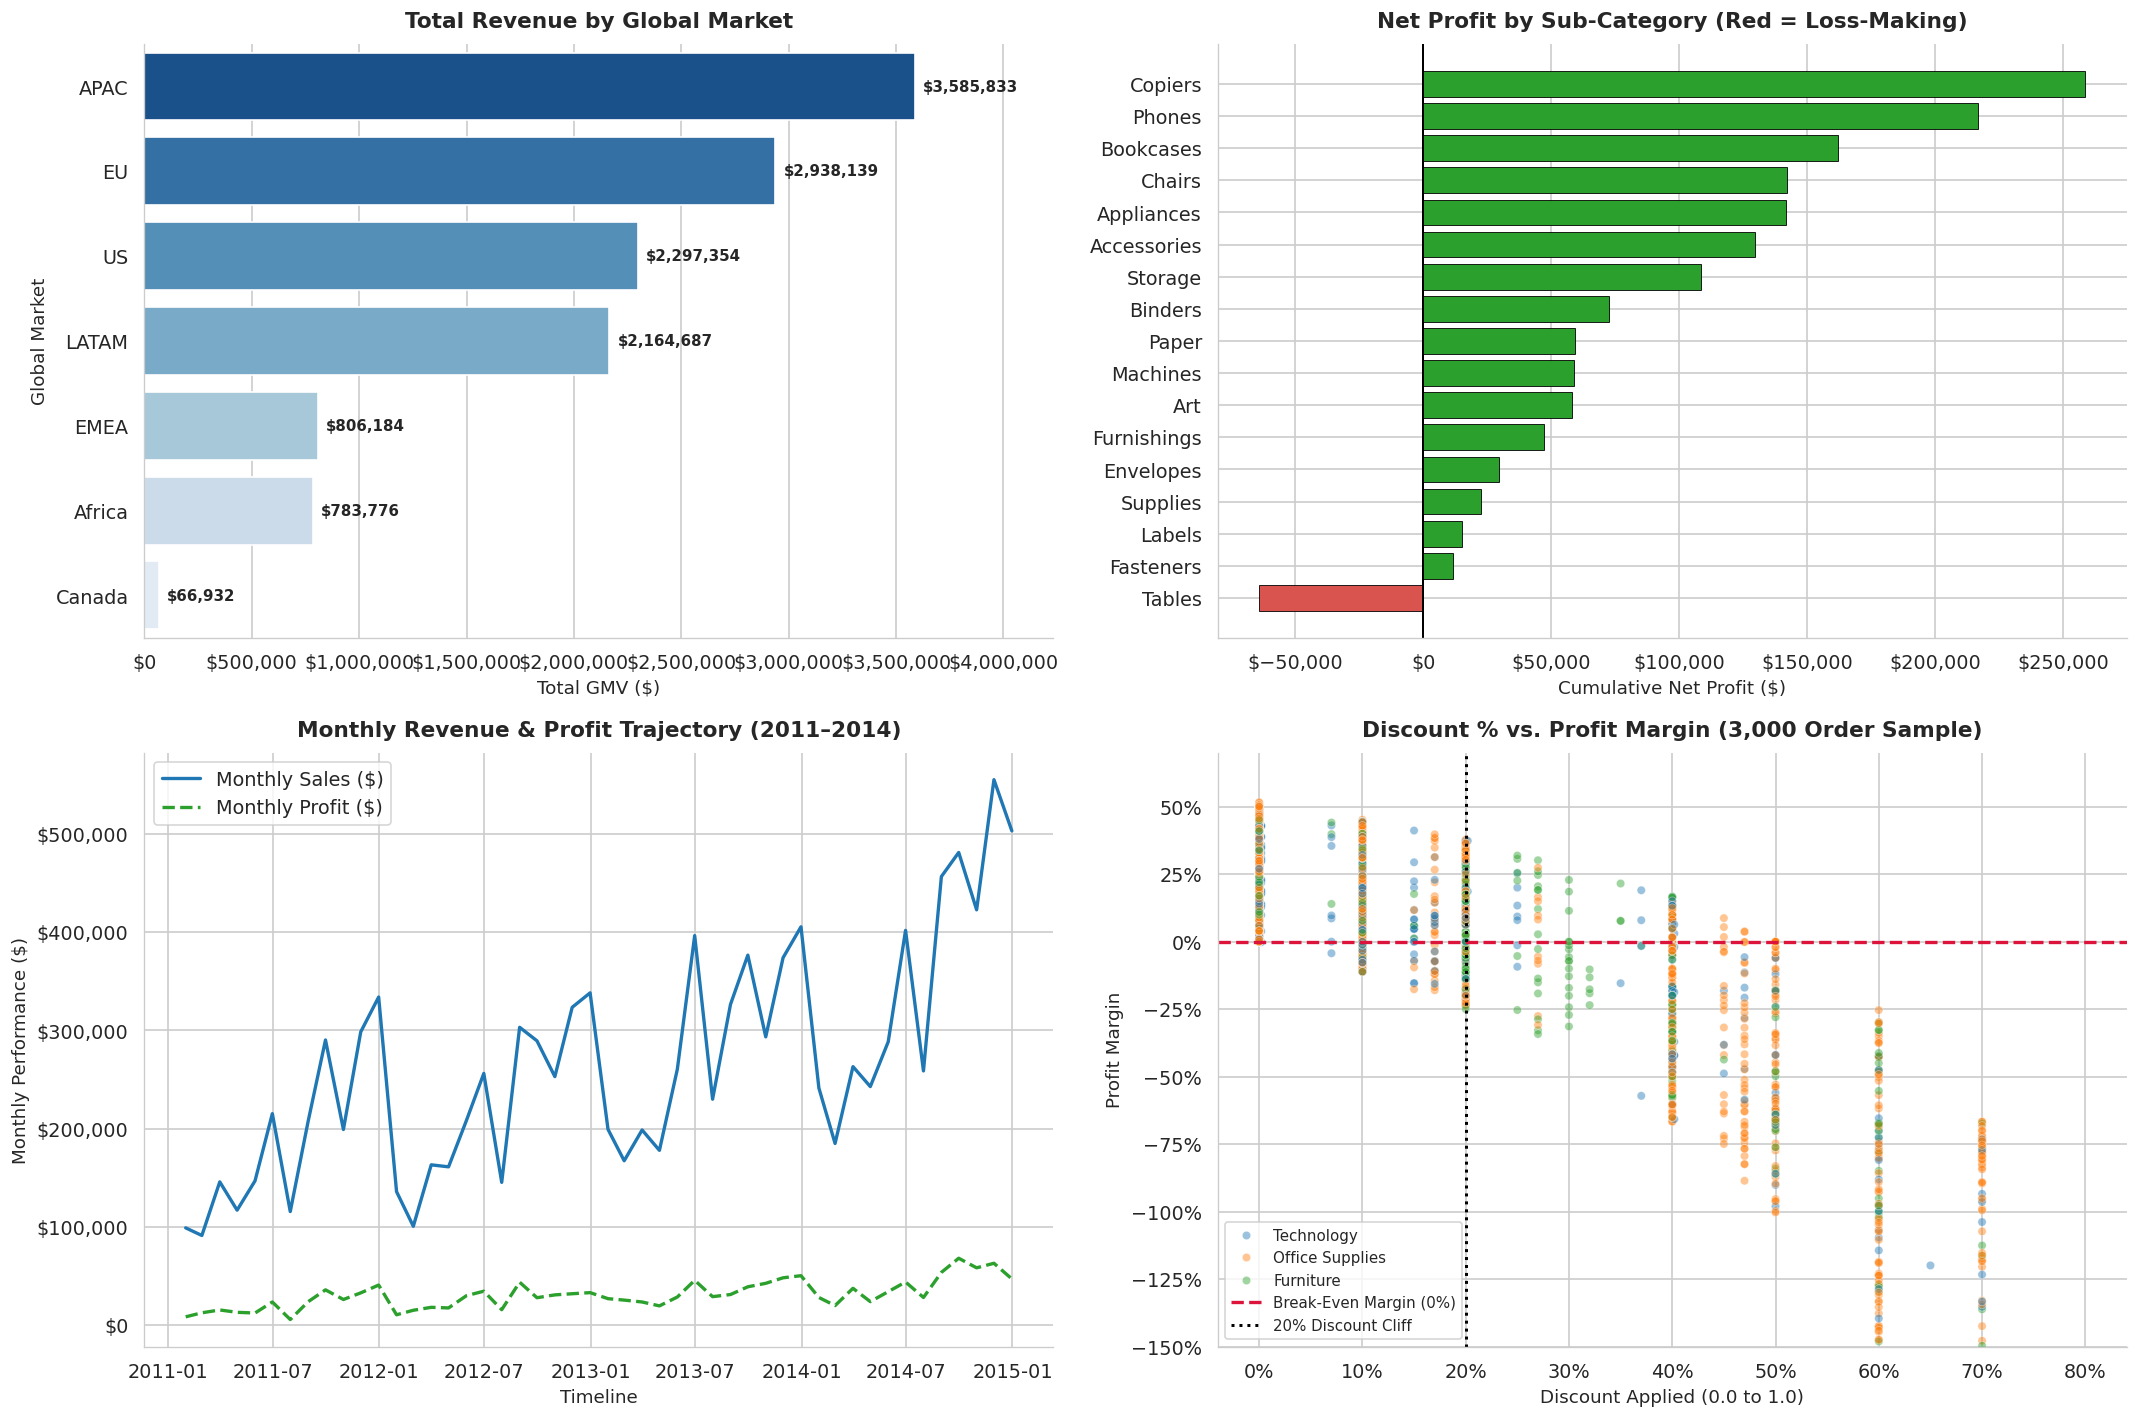

In [8]:
# 37. Multi-Panel Executive Commercial Visual Report
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Panel 1: Bar Chart of Total Revenue by Global Market
market_plot = df.groupby('market')['sales'].sum().sort_values(ascending=False).reset_index()
bars1 = sns.barplot(data=market_plot, x='sales', y='market', ax=axes[0, 0], palette='Blues_r')
axes[0, 0].set_title('Total Revenue by Global Market', fontsize=13, weight='bold', pad=10)
axes[0, 0].set_xlabel('Total GMV ($)', fontsize=11)
axes[0, 0].set_ylabel('Global Market', fontsize=11)
axes[0, 0].xaxis.set_major_formatter(ticker.StrMethodFormatter('${x:,.0f}'))
for p in axes[0, 0].patches:
    val = p.get_width()
    axes[0, 0].annotate(f"${val:,.0f}", (val, p.get_y() + p.get_height() / 2),
                        xytext=(5, 0), textcoords="offset points", ha='left', va='center', fontsize=9, weight='semibold')
axes[0, 0].set_xlim(0, market_plot['sales'].max() * 1.18)
sns.despine(ax=axes[0, 0])

# Panel 2: Net Profit across Sub-Categories (Green = Profit, Red = Loss)
subcat_plot = df.groupby('sub_category')['profit'].sum().sort_values().reset_index()
colors = ['#d9534f' if p < 0 else '#2ca02c' for p in subcat_plot['profit']]
bars2 = axes[0, 1].barh(subcat_plot['sub_category'], subcat_plot['profit'], color=colors, edgecolor='black', linewidth=0.5)
axes[0, 1].axvline(0, color='black', linestyle='-', linewidth=1.2)
axes[0, 1].set_title('Net Profit by Sub-Category (Red = Loss-Making)', fontsize=13, weight='bold', pad=10)
axes[0, 1].set_xlabel('Cumulative Net Profit ($)', fontsize=11)
axes[0, 1].xaxis.set_major_formatter(ticker.StrMethodFormatter('${x:,.0f}'))
sns.despine(ax=axes[0, 1])

# Panel 3: Time Series Monthly Revenue and Profit Trajectory
axes[1, 0].plot(monthly_perf['order_date'], monthly_perf['Monthly_Sales'], color='#1f77b4', linewidth=2, label='Monthly Sales ($)')
axes[1, 0].plot(monthly_perf['order_date'], monthly_perf['Monthly_Profit'], color='#2ca02c', linewidth=2, linestyle='--', label='Monthly Profit ($)')
axes[1, 0].set_title('Monthly Revenue & Profit Trajectory (2011–2014)', fontsize=13, weight='bold', pad=10)
axes[1, 0].set_xlabel('Timeline', fontsize=11)
axes[1, 0].set_ylabel('Monthly Performance ($)', fontsize=11)
axes[1, 0].yaxis.set_major_formatter(ticker.StrMethodFormatter('${x:,.0f}'))
axes[1, 0].legend(loc='upper left', frameon=True)
sns.despine(ax=axes[1, 0])

# Panel 4: Scatter Plot of Discount % vs Profit Margin with Break-Even Line
sample_orders = df.sample(n=3000, random_state=42)
sns.scatterplot(data=sample_orders, x='discount', y='profit_margin', hue='category', alpha=0.45, s=25, ax=axes[1, 1], palette='tab10')
axes[1, 1].axhline(0, color='crimson', linestyle='--', linewidth=2, label='Break-Even Margin (0%)')
axes[1, 1].axvline(0.20, color='black', linestyle=':', linewidth=1.8, label='20% Discount Cliff')
axes[1, 1].set_title('Discount % vs. Profit Margin (3,000 Order Sample)', fontsize=13, weight='bold', pad=10)
axes[1, 1].set_xlabel('Discount Applied (0.0 to 1.0)', fontsize=11)
axes[1, 1].set_ylabel('Profit Margin', fontsize=11)
axes[1, 1].xaxis.set_major_formatter(ticker.PercentFormatter(xmax=1.0, decimals=0))
axes[1, 1].yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1.0, decimals=0))
axes[1, 1].set_ylim(-1.5, 0.7)
axes[1, 1].legend(loc='lower left', frameon=True, fontsize=9)
sns.despine(ax=axes[1, 1])

plt.tight_layout()
plt.show()

---
## 🎯 Strategic Recommendations & Action Plan

```mermaid
flowchart TD
    A["Commercial Audit Diagnoses"] --> B["1. Hard Cap Discounting at 20%"]
    A --> C["2. Restructure or Discontinue 'Tables'"]
    A --> D["3. Immediate Intervention in 5 Loss Countries"]
    A --> E["4. Capitalize on Q4 Holiday Demand Surge"]
```

### 1. Enforce Hard 20% Discount Guardrails (Immediate $500k+ Margin Recovery)
* **Finding**: Orders discounted >20% suffer average negative profits (-$55 to -$97 per order), causing $920k in cumulative losses.
* **Action**: Implement automated checkout rules preventing sales reps from applying discounts exceeding 20% without regional VP approval.

### 2. Restructure the "Tables" Product Line (-$64k Deficit)
* **Finding**: Tables generate $758k in sales but produce a -$64,083 cumulative loss due to freight weight and high discount allowances (avg 28.9%).
* **Action**: Renegotiate freight logistics contracts for flat-pack table manufacturers, pass bulk shipping surcharges to buyers, and restrict promotional discounting to a maximum of 10%.

### 3. Regional Pricing Overhaul for Top Loss Geographies (-$272k Bleed)
* **Finding**: Turkey (-$98k), Nigeria (-$80k), Netherlands (-$41k), Honduras (-$29k), and Pakistan (-$22k) represent acute loss centers.
* **Action**: Transition from local currency pricing to USD-pegged pricing to protect against foreign exchange devaluation, and adjust minimum order sizes for international shipping.

### 4. Supply Chain Readiness for Q4 Peak Season
* **Finding**: November and December consistently represent the annual revenue and profit peaks (~3x January volume).
* **Action**: Align warehouse labor scheduling and carrier inventory commitments 60 days ahead of October to avoid express carrier surcharges.
